In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
tt = pd.read_csv(r"C:\Users\YASH\Downloads/train.csv")
tt.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [3]:
print("Number of rows:", tt.shape[0])
print("Number of columns:", tt.shape[1])

Number of rows: 891
Number of columns: 12


In [4]:
print("Numerical Column Statistics:")
display(tt.describe())

print("\nCategorical Column Statistics:")
display(tt.describe(include='object'))

Numerical Column Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Categorical Column Statistics:


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [5]:
# Data Quality Report
quality_report = pd.DataFrame({
    'Column': tt.columns,
    'Data Type': tt.dtypes.astype(str).values,
    'Missing Values': tt.isnull().sum().values,
    'Missing Percentage': (
        tt.isnull().sum().values / len(tt) * 100
    ).round(2),
    'Unique Values': tt.nunique().values
})
print("DATA QUALITY REPORT")
display(quality_report)

DATA QUALITY REPORT


,Column,Data Type,Missing Values,Missing Percentage,Unique Values
0,PassengerId,int64,0,0.00,891
1,Survived,int64,0,0.00,2
2,Pclass,int64,0,0.00,3
3,Name,object,0,0.00,891
4,Sex,object,0,0.00,2
5,Age,float64,177,19.87,88
6,SibSp,int64,0,0.00,7
7,Parch,int64,0,0.00,7
8,Ticket,object,0,0.00,681
9,Fare,float64,0,0.00,248


In [6]:
tt.duplicated().sum()   # Output for duplicate rows.

0

In [7]:
# Numeric Range Report
numeric_columns = tt.select_dtypes(include=np.number).columns
range_report = pd.DataFrame({
    'Minimum': tt[numeric_columns].min(),
    'Maximum': tt[numeric_columns].max(),
    'Mean': tt[numeric_columns].mean(),
    'Median': tt[numeric_columns].median()
})
print("NUMERIC RANGE REPORT")
display(range_report)

NUMERIC RANGE REPORT


,Minimum,Maximum,Mean,Median
PassengerId,1.00,891.0000,446.000000,446.0000
Survived,0.00,1.0000,0.383838,0.0000
Pclass,1.00,3.0000,2.308642,3.0000
Age,0.42,80.0000,29.699118,28.0000
SibSp,0.00,8.0000,0.523008,0.0000
Parch,0.00,6.0000,0.381594,0.0000
Fare,0.00,512.3292,32.204208,14.4542


In [8]:
# Before Statistic
before_rows = len(tt)
before_duplicates = tt.duplicated().sum()
before_nulls = tt.isnull().sum().sum()

before_summary = pd.DataFrame({
    'Metric': [
        'Row Count',
        'Duplicate Rows',
        'Total Missing Values'
    ],
    'Before Cleaning': [
        before_rows,
        before_duplicates,
        before_nulls
    ]
})
display(before_summary)

,Metric,Before Cleaning
0,Row Count,891
1,Duplicate Rows,0
2,Total Missing Values,866


In [9]:
# Missing value Analysis
missing_summary = pd.DataFrame({
    'Missing Values': tt.isnull().sum(),
    'Missing Percentage': (
        tt.isnull().sum() / len(tt) * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary['Missing Values'] > 0
].sort_values(
    by='Missing Values',
    ascending=False
)
display(missing_summary)

,Missing Values,Missing Percentage
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


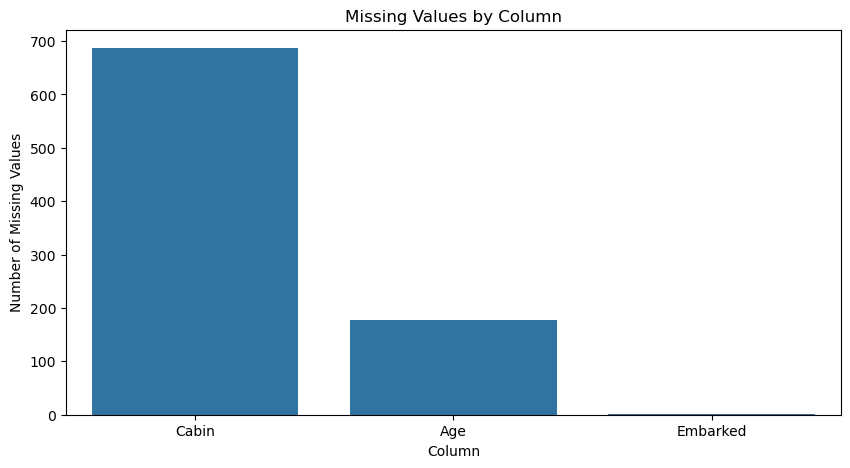

In [10]:
# Visualize Missing Values
plt.figure(figsize=(10, 5))
sns.barplot(
    x=missing_summary.index,
    y=missing_summary['Missing Values']
)
plt.title('Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('Number of Missing Values')
plt.show()

In [11]:
# Handle Missing Values
print("Missing values before cleaning:")
print(tt.isnull().sum())

# Fill Age using median
tt['Age'] = tt['Age'].fillna(tt['Age'].median())

# Fill Embarked using mode
tt['Embarked'] = tt['Embarked'].fillna(tt['Embarked'].mode()[0])

# Drop Cabin because of extensive missing data
tt = tt.drop(columns=['Cabin'])

print("\nMissing values after cleaning:")
print(tt.isnull().sum())

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Missing Value Handling

- **Age:** Missing values were replaced with the median because Age is a numerical variable and the median is less sensitive to extreme values.
- **Embarked:** Missing values were replaced with the mode because Embarked is a categorical variable.
- **Cabin:** The Cabin column was removed because 77.10% of its values were missing, making reliable imputation difficult.

In [12]:
print("Unique values before standardisation:")

print("\nSex:")
print(tt['Sex'].unique())

print("\nEmbarked:")
print(tt['Embarked'].unique())

Unique values before standardisation:

Sex:
['male' 'female']

Embarked:
['S' 'C' 'Q']


In [13]:
# Standardise Sex values
tt['Sex'] = tt['Sex'].str.strip().str.title()

# Standardise Embarked values
tt['Embarked'] = tt['Embarked'].str.strip().str.upper()

print("Unique values after standardisation:")

print("\nSex:")
print(tt['Sex'].unique())

print("\nEmbarked:")
print(tt['Embarked'].unique())

Unique values after standardisation:

Sex:
['Male' 'Female']

Embarked:
['S' 'C' 'Q']


In [14]:
# Passenger ID
tt['PassengerId'] = pd.to_numeric(
    tt['PassengerId'],
    errors='coerce'
).astype('Int64')

# Age
tt['Age'] = pd.to_numeric(
    tt['Age'],
    errors='coerce'
)

# Fare
tt['Fare'] = pd.to_numeric(
    tt['Fare'],
    errors='coerce'
)

# Pclass
tt['Pclass'] = pd.to_numeric(
    tt['Pclass'],
    errors='coerce'
).astype('Int64')

# SibSp
tt['SibSp'] = pd.to_numeric(
    tt['SibSp'],
    errors='coerce'
).astype('Int64')

# Parch
tt['Parch'] = pd.to_numeric(
    tt['Parch'],
    errors='coerce'
).astype('Int64')

print("Updated Data Types:")
print(tt.dtypes)

Updated Data Types:
PassengerId      Int64
Survived         int64
Pclass           Int64
Name            object
Sex             object
Age            float64
SibSp            Int64
Parch            Int64
Ticket          object
Fare           float64
Embarked        object
dtype: object


In [16]:
numeric_columns = ['Age', 'Fare', 'SibSp', 'Parch']
outlier_report = []
for column in numeric_columns:

    Q1 = tt[column].quantile(0.25)
    Q3 = tt[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = tt[
        (tt[column] < lower_bound) |
        (tt[column] > upper_bound)
    ]
    outlier_report.append({
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outliers': len(outliers)
    })

outlier_report = pd.DataFrame(outlier_report)
display(outlier_report)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers
0,Age,22.0000,35.0,13.0000,2.500,54.5000,66
1,Fare,7.9104,31.0,23.0896,-26.724,65.6344,116
2,SibSp,0.0000,1.0,1.0000,-1.500,2.5000,46
3,Parch,0.0000,0.0,0.0000,0.000,0.0000,213


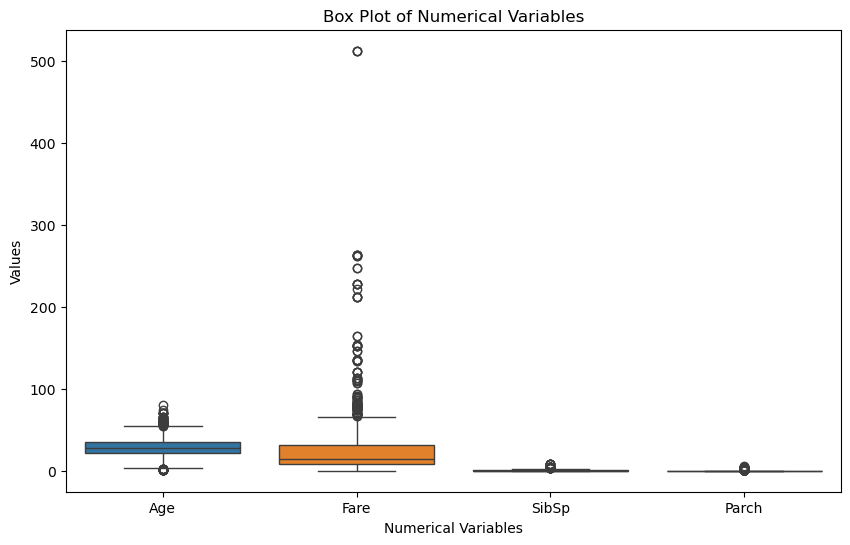

In [17]:
# Visualize Outlier using Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=tt[numeric_columns]
)
plt.title('Box Plot of Numerical Variables')
plt.xlabel('Numerical Variables')
plt.ylabel('Values')
plt.show()

In [18]:
# Handle outlier

In [20]:
# Handle outliers using the IQR method

for column in numeric_columns:

    Q1 = tt[column].quantile(0.25)
    Q3 = tt[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Convert column to float so decimal IQR boundaries can be applied
    tt[column] = tt[column].astype(float)

    # Cap outliers at IQR boundaries
    tt[column] = tt[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )
print("Outliers have been capped using the IQR method.")

Outliers have been capped using the IQR method.


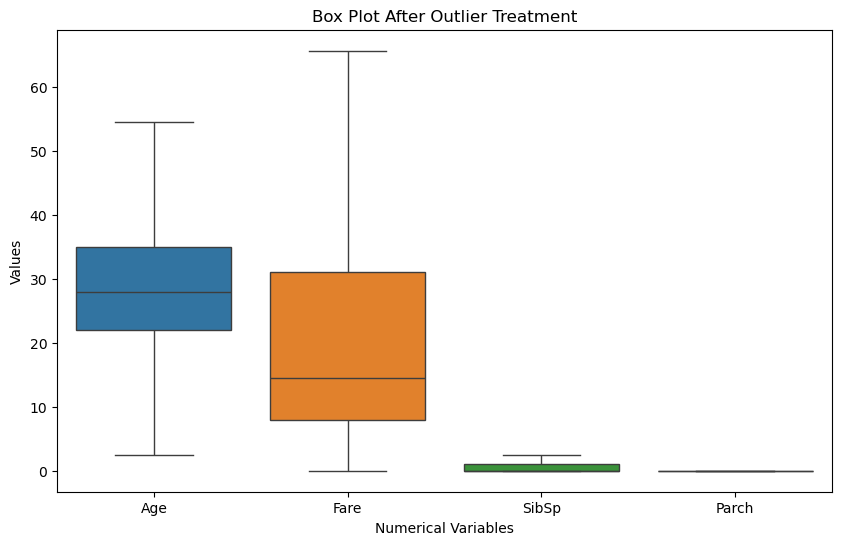

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=tt[numeric_columns]
)
plt.title('Box Plot After Outlier Treatment')
plt.xlabel('Numerical Variables')
plt.ylabel('Values')
plt.show()

In [22]:
# Final Check
print("Missing values after cleaning:")
display(
    tt.isnull().sum().to_frame(
        name='Missing Values'
    )
)

Missing values after cleaning:


,Missing Values
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [23]:
print("Duplicate rows after cleaning:", tt.duplicated().sum())

Duplicate rows after cleaning: 0


In [24]:
print("Final Data Types:")
print(tt.dtypes)

Final Data Types:
PassengerId      Int64
Survived         int64
Pclass           Int64
Name            object
Sex             object
Age            float64
SibSp          float64
Parch          float64
Ticket          object
Fare           float64
Embarked        object
dtype: object


In [25]:
# Comparision before and after
after_rows = len(tt)
after_duplicates = tt.duplicated().sum()
after_nulls = tt.isnull().sum().sum()

comparison = pd.DataFrame({
    'Metric': [
        'Row Count',
        'Duplicate Rows',
        'Total Missing Values'
    ],
    'Before Cleaning': [
        before_rows,
        before_duplicates,
        before_nulls
    ],
    'After Cleaning': [
        after_rows,
        after_duplicates,
        after_nulls
    ]
})
display(comparison)

,Metric,Before Cleaning,After Cleaning
0,Row Count,891,891
1,Duplicate Rows,0,0
2,Total Missing Values,866,0


In [26]:
print("Final Dataset Shape:", tt.shape)

print("\nFinal Columns:")
print(tt.columns.tolist())

print("\nFinal Dataset:")
display(tt.head(10))

Final Dataset Shape: (891, 11)

Final Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']

Final Dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1.0,0.0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1.0,0.0,PC 17599,65.6344,C
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1.0,0.0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0.0,0.0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",Male,28.0,0.0,0.0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",Male,54.0,0.0,0.0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",Male,2.5,2.5,0.0,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",Female,27.0,0.0,0.0,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",Female,14.0,1.0,0.0,237736,30.0708,C


In [27]:
output_file = 'titanic_cleaned.csv'

tt.to_csv(
    output_file,
    index=False
)
print("Cleaned dataset saved successfully!")
print("File name:", output_file)

Cleaned dataset saved successfully!
File name: titanic_cleaned.csv


In [29]:
cleaned_tt = pd.read_csv(output_file)
print("Saved file loaded successfully!")
print("Shape:", cleaned_tt.shape)
display(cleaned_tt.head(2))

Saved file loaded successfully!
Shape: (891, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1.0,0.0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1.0,0.0,PC 17599,65.6344,C


# Conclusion

The Titanic dataset was successfully transformed into a clean and analysis-ready dataset.

The cleaning process included missing-value handling, duplicate removal, categorical data standardisation, data type correction, and outlier detection using the IQR method.

Missing Age values were replaced using the median, missing Embarked values were replaced using the mode, and the Cabin column was removed because of its high percentage of missing values.

Potential numerical outliers were identified using the IQR method and capped at the calculated boundaries while retaining the original records.

A before-vs-after comparison was created to document the impact of the cleaning process. The final cleaned dataset was saved as `titanic_cleaned.csv`.

This project demonstrates a structured and reproducible approach to professional data cleaning using Python, pandas, and NumPy.